# E15 Matrix Sensing Negative-Control Regime

### Problem

This notebook treats direct Matrix Sensing as a negative control. The layerwise activation-stable-rank structure from the spectral-update theory is absent here, so Muon-family methods are not expected to automatically dominate.

The goal is to verify the conditional theory: sample complexity should improve recovery, but Muon advantage should not appear unless favourable gradient-spectrum conditions appear.

## Implementation Details: Skip Unless Modifying The Experiment

In [1]:
import math
import os
import pathlib
import sys
import time
from itertools import product

for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Documents/Workspace/MUONexperiment
torch   = 2.11.0


### Parameters And Runs

In [2]:
NOTEBOOK_ID = "E15 Matrix Sensing negative control"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon", "Muon-Exact", "Muon-NS-1", "NormalizedSGD", "SpectralNormSGD", "Adam", "SGD"]
SEEDS = list(range(5))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 1200

BASE_SPEC = dict(problem="MatrixSensing", d=60, rank=5, lr=0.01, noise=0.0, dist="normal", init_scale=1e-2,
                 iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS, diagnostic_every=1 if SMOKE_TEST else 20,
                 early_stop=True, early_stop_min_steps=100, early_stop_patience=20, early_stop_min_delta=1e-8,
                 device_type=DEVICE.type, dtype_name=DTYPE_NAME)
SPECTRUM_CASES = [
    dict(spectrum_case="hard-k1", spectrum="hard-cutoff", kappa=1.0),
    dict(spectrum_case="exp-k10", spectrum="exponential-decay", kappa=10.0),
    dict(spectrum_case="exp-k100", spectrum="exponential-decay", kappa=100.0),
]
M_MULTIPLIERS = [1, 2, 4, 8, 16]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([{**BASE_SPEC, **case, "m_multiplier": alpha, "algo": algo, "seed": seed}
                     for case in SPECTRUM_CASES for alpha in M_MULTIPLIERS for algo in ALGOS for seed in SEEDS])
runs.insert(0, "run_id", range(len(runs)))
print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
runs=525, max_total_steps=630000


,run_id,problem,d,rank,lr,noise,dist,init_scale,iters,diagnostic_every,...,early_stop_patience,early_stop_min_delta,device_type,dtype_name,spectrum_case,spectrum,kappa,m_multiplier,algo,seed
0,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,20,1.000000e-08,cpu,float64,hard-k1,hard-cutoff,1.0,1,Muon,0
1,1,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,20,1.000000e-08,cpu,float64,hard-k1,hard-cutoff,1.0,1,Muon,1
2,2,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,20,1.000000e-08,cpu,float64,hard-k1,hard-cutoff,1.0,1,Muon,2
3,3,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,20,1.000000e-08,cpu,float64,hard-k1,hard-cutoff,1.0,1,Muon,3
4,4,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,20,1.000000e-08,cpu,float64,hard-k1,hard-cutoff,1.0,1,Muon,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,520,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,20,1.000000e-08,cpu,float64,exp-k100,exponential-decay,100.0,16,SGD,0
521,521,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,20,1.000000e-08,cpu,float64,exp-k100,exponential-decay,100.0,16,SGD,1
522,522,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,20,1.000000e-08,cpu,float64,exp-k100,exponential-decay,100.0,16,SGD,2
523,523,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,20,1.000000e-08,cpu,float64,exp-k100,exponential-decay,100.0,16,SGD,3


### Pseudocode

```text
for each spectrum, sample-complexity multiplier, optimizer, seed:
    build MatrixSensing problem with repo constructor
    train direct matrix variable X
    record training loss, recovery error, gradient diagnostics, and Muon-vs-baseline gaps
```

### Worker Definition

In [3]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_generator(seed, device):
    try:
        return torch.Generator(device=device).manual_seed(int(seed))
    except Exception:
        return torch.Generator().manual_seed(int(seed))


def randn(shape, seed, device, dtype):
    shape = tuple(int(dim) for dim in shape)
    return torch.randn(shape, generator=make_generator(seed, device), device=device, dtype=dtype)


def make_optimizer(algo, params, lr, rank=None):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-Exact":
        return optimizers.MuonExact(params, lr=lr, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-5":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, variant="randsvd", rank=rank)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="spectral", momentum=0.0)
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr)
    raise ValueError(f"unknown optimizer: {algo}")


def nuclear_fro_ratio(matrix, epsilon=1e-12):
    singular_values = torch.linalg.svdvals(matrix.detach())
    numerator = singular_values.sum().square()
    denominator = singular_values.square().sum().clamp_min(epsilon)
    return float((numerator / denominator).detach().cpu())


def relative_update_diagnostics(params_before, params_after, gradients):
    updates = [after.detach() - before.detach() for before, after in zip(params_before, params_after)]
    return {
        "descent_alignment": util.diagnostics.descent_alignment(gradients, updates),
        "relative_step_size": util.diagnostics.relative_step_size(params_before, updates),
        **util.diagnostics.aggregate_matrix_diagnostics(updates, prefix="update"),
        **util.diagnostics.aggregate_matrix_diagnostics(gradients, prefix="grad"),
    }


def summarize_last_rows(runs, group_columns):
    ordered = runs.sort_values(["run_id", "step"])
    return ordered.groupby(group_columns, as_index=False, observed=True).tail(1).reset_index(drop=True)

def single_run(run):
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)
    device = torch.device(run["device_type"])
    problem = problems.MatrixSensing.make_matrix_sensing_problem(
        run["d"], run["rank"], noise=run["noise"], dist=run["dist"], spectrum=run["spectrum"], kappa=run["kappa"],
        seed=run["seed"], device=device, dtype=dtype, m_multiplier=run["m_multiplier"])
    x = (run["init_scale"] * randn((run["d"], run["d"]), run["seed"] + 10, device, dtype)).requires_grad_(True)
    params = [x]
    opt = make_optimizer(run["algo"], params, run["lr"], rank=run["rank"])
    initial_loss = float(problem.loss(x).detach().cpu())
    best_loss = initial_loss
    wait = 0
    rows = []
    start = time.perf_counter()
    stop_reason = "max_steps"
    for step in range(int(run["iters"]) + 1):
        do_diag = (step == 0) or (step == run["iters"]) or (step % int(run["diagnostic_every"]) == 0)
        if do_diag:
            loss_value = float(problem.loss(x).detach().cpu())
            row = {**run, "step": step, "initial_loss": initial_loss, "loss": loss_value,
                   "best_loss": best_loss, "recovery_error": util.diagnostics.relative_matrix_error(x, problem.target),
                   "gradient_nuclear_fro_ratio": np.nan, "elapsed_s": time.perf_counter() - start, "stop_reason": stop_reason}
            # Estimate gradient-spectrum diagnostic without changing state.
            if x.grad is not None:
                x.grad = None
            problem.loss(x).backward()
            grad = x.grad.detach().clone()
            row["gradient_nuclear_fro_ratio"] = nuclear_fro_ratio(grad)
            row.update(util.diagnostics.aggregate_matrix_diagnostics([grad], prefix="grad"))
            x.grad = None
            rows.append(row)
        if step == run["iters"]:
            break
        loss = problem.loss(x)
        loss.backward()
        opt.step()
        x.grad = None
        current = float(problem.loss(x).detach().cpu())
        if best_loss - current > run["early_stop_min_delta"]:
            best_loss = current
            wait = 0
        else:
            wait += 1
        if run["early_stop"] and step >= run["early_stop_min_steps"] and wait >= run["early_stop_patience"]:
            stop_reason = "early_stop"
            break
    return pd.DataFrame(rows)


## Results

In [4]:
runs = util.run_experiments(runs, single_run, num_workers=NUM_WORKERS, backend=JOBLIB_BACKEND,
                            algo_order=ALGOS, sort_columns=("run_id", "step"), desc=NOTEBOOK_ID)
IPython.display.display(runs)


E15 Matrix Sensing negative control:   0%|          | 0/525 [00:00<?, ?run/s]

E15 Matrix Sensing negative control:   0%|          | 1/525 [00:02<25:35,  2.93s/run]

E15 Matrix Sensing negative control:   4%|▍         | 22/525 [00:03<01:11,  7.03run/s]

E15 Matrix Sensing negative control:   7%|▋         | 38/525 [00:05<00:50,  9.67run/s]

E15 Matrix Sensing negative control:  10%|█         | 53/525 [00:06<00:44, 10.69run/s]

...

E15 Matrix Sensing negative control:  99%|█████████▉| 519/525 [07:04<00:09,  1.58s/run]

E15 Matrix Sensing negative control:  99%|█████████▉| 520/525 [07:06<00:07,  1.53s/run]

E15 Matrix Sensing negative control:  99%|█████████▉| 521/525 [07:54<00:36,  9.22s/run]

E15 Matrix Sensing negative control: 100%|██████████| 525/525 [07:55<00:00,  1.10run/s]

,run_id,problem,d,rank,lr,noise,dist,init_scale,iters,diagnostic_every,...,loss,best_loss,recovery_error,gradient_nuclear_fro_ratio,elapsed_s,stop_reason,grad_fro_norm,grad_op_norm,grad_effective_rank,grad_stable_rank
0,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,2.416112,2.416112,1.036621,42.390355,0.000251,max_steps,7.827600,1.930453,47.572630,16.441404
1,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,0.363146,0.078981,1.051170,40.822454,0.100777,max_steps,2.767747,0.733512,46.256452,14.237669
2,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,0.061054,0.052153,1.034072,42.726144,0.172271,max_steps,1.117460,0.296412,48.019970,14.212603
3,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,0.016746,0.015710,1.032825,42.278215,0.222879,max_steps,0.618880,0.153926,47.405964,16.165399
4,0,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,0.011121,0.009156,1.033096,42.882707,0.273575,max_steps,0.556352,0.139166,48.002406,15.982010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6629,524,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,0.002411,0.002411,0.203424,38.521135,51.605497,max_steps,0.020310,0.008269,45.653106,6.031802
6630,524,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,0.002331,0.002331,0.200939,38.600594,52.367903,max_steps,0.019841,0.008040,45.698233,6.089601
6631,524,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,0.002254,0.002254,0.198506,38.677365,53.049573,max_steps,0.019390,0.007821,45.741737,6.146975
6632,524,MatrixSensing,60,5,0.01,0.0,normal,0.01,1200,20,...,0.002180,0.002180,0.196125,38.751550,53.369034,max_steps,0.018956,0.007611,45.783752,6.203934


### Result Tables

In [5]:
run_summary = summarize_last_rows(runs, ["run_id"])
summary = run_summary.groupby(["spectrum_case", "m_multiplier", "algo"], as_index=False, observed=True).agg(
    median_recovery=("recovery_error", "median"), median_loss=("loss", "median"),
    median_gradient_score=("gradient_nuclear_fro_ratio", "median"), median_grad_effective_rank=("grad_effective_rank", "median"),
)
IPython.display.display(summary.sort_values(["spectrum_case", "m_multiplier", "median_recovery"]))


,spectrum_case,m_multiplier,algo,median_recovery,median_loss,median_gradient_score,median_grad_effective_rank
5,exp-k10,1,SGD,1.043403,2.570063e-09,43.039613,48.151694
4,exp-k10,1,NormalizedSGD,1.043405,2.361447e-04,42.807192,47.902874
6,exp-k10,1,SpectralNormSGD,1.043434,4.466867e-03,42.885612,48.004295
3,exp-k10,1,Muon-NS-1,1.046398,7.464656e-04,43.102960,48.062536
0,exp-k10,1,Adam,1.071657,4.994883e-09,43.077603,48.245362
...,...,...,...,...,...,...,...
101,hard-k1,16,Muon-NS-1,0.004041,1.364845e-04,43.731386,48.435801
104,hard-k1,16,SpectralNormSGD,0.016952,1.136031e-03,43.135638,48.204883
99,hard-k1,16,Muon,0.038650,3.297971e-03,44.270450,49.023523
100,hard-k1,16,Muon-Exact,0.103458,7.217597e-03,43.781193,48.765248


### Sample Complexity Vs Recovery

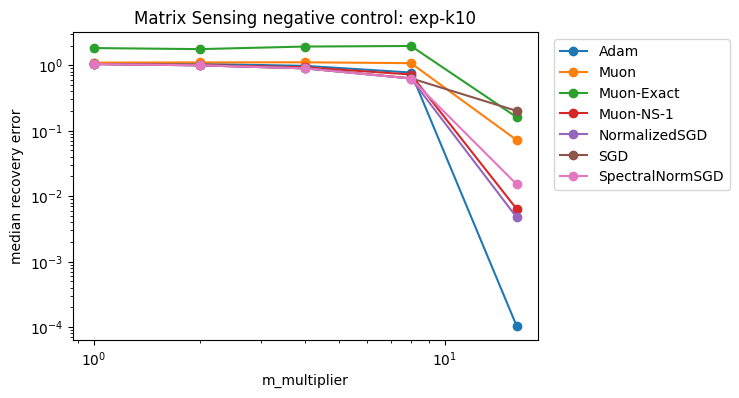

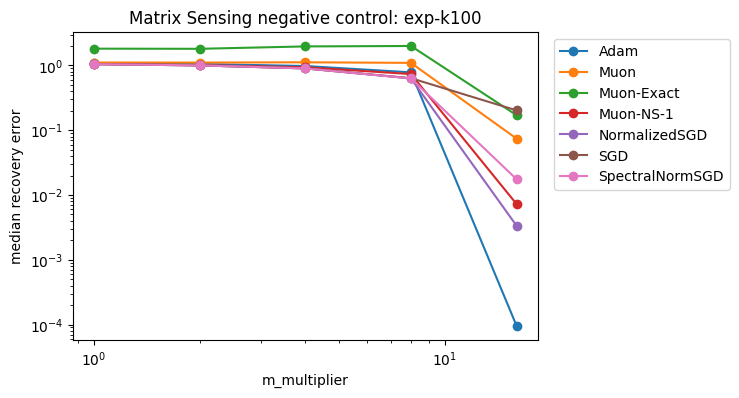

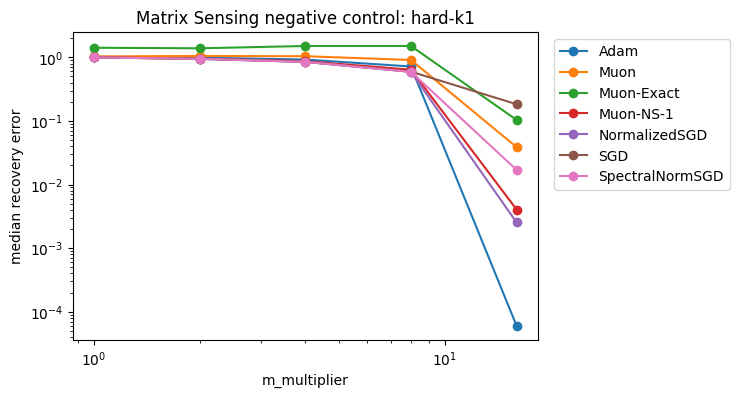

In [6]:
for spectrum_case in sorted(summary["spectrum_case"].unique()):
    fig, ax = plt.subplots(figsize=(6, 4))
    sub = summary[summary["spectrum_case"] == spectrum_case]
    for algo, group in sub.groupby("algo", observed=True):
        ax.plot(group["m_multiplier"], group["median_recovery"], marker="o", label=algo)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("m_multiplier")
    ax.set_ylabel("median recovery error")
    ax.set_title(f"Matrix Sensing negative control: {spectrum_case}")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()


### Muon-Exact Vs Adam Gap

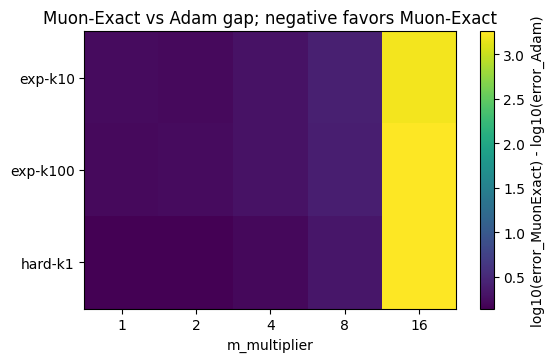

In [7]:
pivot = run_summary.pivot_table(index=["spectrum_case", "m_multiplier", "seed"], columns="algo", values="recovery_error", observed=True).reset_index()
if {"Muon-Exact", "Adam"}.issubset(pivot.columns):
    pivot["gap"] = np.log10(pivot["Muon-Exact"].clip(lower=1e-12)) - np.log10(pivot["Adam"].clip(lower=1e-12))
    heat = pivot.pivot_table(index="spectrum_case", columns="m_multiplier", values="gap", aggfunc="median", observed=True)
    fig, ax = plt.subplots(figsize=(6, 3.6))
    im = ax.imshow(heat.values, aspect="auto")
    ax.set_yticks(range(len(heat.index)), heat.index)
    ax.set_xticks(range(len(heat.columns)), [str(c) for c in heat.columns])
    ax.set_xlabel("m_multiplier")
    ax.set_title("Muon-Exact vs Adam gap; negative favors Muon-Exact")
    plt.colorbar(im, ax=ax, label="log10(error_MuonExact) - log10(error_Adam)")
    plt.show()


### Reading The Result

This experiment supports the negative-control narrative if sample complexity improves recovery but Muon-family methods do not systematically dominate Adam or SGD. If Muon begins to win in a subset, inspect the gradient nuclear/Frobenius ratio and effective rank to identify whether a favourable spectral condition has emerged.